Análisis de Datos CSV Agrupación

Importar librerías

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

CARGAR ARCHIVO CSV

In [2]:
url_agrupacion = "https://raw.githubusercontent.com/eduardorivas2517502022/Parcial4-RivasEduardo-2517502022/refs/heads/main/csv/clave_G_agrupacion.csv"

df_agrupacion = pd.read_csv(url_agrupacion)

df_agrupacion.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,G-R0007,33,631,3.98,15.70,6.07,3,1
1,G-R0123,44,995,6.13,75.82,7.87,2,32
2,G-R0009,28,509,1.30,30.45,5.97,5,1
3,G-R0228,46,769,2.94,69.77,5.28,12,21
4,G-R0106,37,1069,5.56,83.50,8.27,1,8


REVISAR ESTRUCTURA DEL DATASET y Reemplazar valores nulos

In [3]:
df_agrupacion.info()
df_agrupacion.isnull().sum()
df_agrupacion['satisfaccion'] = df_agrupacion['satisfaccion'].fillna(df_agrupacion['satisfaccion'].median())
df_agrupacion.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       254 non-null    object 
 1   edad              254 non-null    int64  
 2   ingresos          254 non-null    int64  
 3   frecuencia_uso    254 non-null    float64
 4   gasto_promedio    254 non-null    float64
 5   satisfaccion      253 non-null    float64
 6   reclamos          254 non-null    int64  
 7   antiguedad_meses  254 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 16.0+ KB


np.int64(0)

Seleccionar variables para clustering

In [11]:
variables_cluster = df_agrupacion[
    [
        'edad',
        'ingresos',
        'frecuencia_uso',
        'gasto_promedio',
        'satisfaccion',
        'reclamos',
        'antiguedad_meses'
    ]
].copy()

Convertir datos numéricos, Reemplazar valores faltantes y Escalar o normalizar datos

In [12]:
variables_cluster = variables_cluster.apply(pd.to_numeric, errors='coerce')
variables_cluster = variables_cluster.fillna(variables_cluster.mean())

scaler = StandardScaler()

variables_escaladas = scaler.fit_transform(variables_cluster)

Método del codo

In [13]:
inercias = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(variables_escaladas)
    inercias.append(modelo.inertia_)

Graficar método del codo

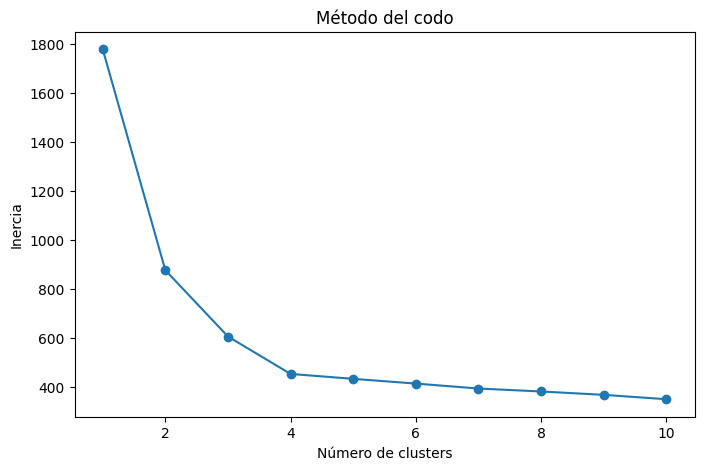

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inercias, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.show()

Aplicar K-Means

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df_agrupacion['cluster'] = kmeans.fit_predict(variables_escaladas)

df_agrupacion.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,G-R0007,33,631,3.98,15.70,6.07,3,1,1
1,G-R0123,44,995,6.13,75.82,7.87,2,32,0
2,G-R0009,28,509,1.30,30.45,5.97,5,1,1
3,G-R0228,46,769,2.94,69.77,5.28,12,21,1
4,G-R0106,37,1069,5.56,83.50,8.27,1,8,0


Contar clientes por grupo y Promedio de variables por cluster

In [16]:
df_agrupacion['cluster'].value_counts()
df_agrupacion.groupby('cluster')[
    [
        'edad',
        'ingresos',
        'frecuencia_uso',
        'gasto_promedio',
        'satisfaccion',
        'reclamos',
        'antiguedad_meses'
    ]
].mean()

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0,37.736111,1124.291667,6.634861,88.429167,8.353056,0.902778,18.444444
1,35.549180,768.196721,3.142295,48.886967,5.254590,4.237705,10.393443
2,51.366667,1731.666667,9.075500,157.002333,8.972712,0.616667,38.016667


Visualización de clusters

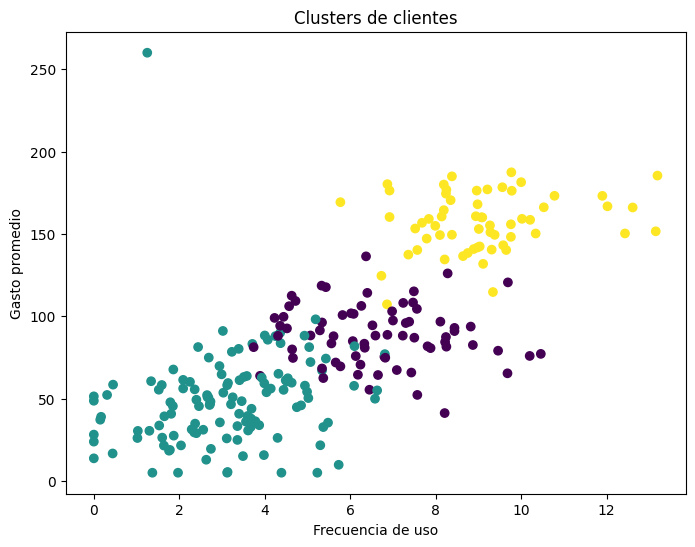

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_agrupacion['frecuencia_uso'],
    df_agrupacion['gasto_promedio'],
    c=df_agrupacion['cluster']
)

plt.xlabel('Frecuencia de uso')
plt.ylabel('Gasto promedio')
plt.title('Clusters de clientes')
plt.show()

Guardar dataset final

In [18]:
df_agrupacion.to_csv('dataset_con_clusters.csv', index=False)

print("Archivo dataset_con_clusters.csv creado correctamente")

Archivo dataset_con_clusters.csv creado correctamente
